In [1]:
!pip install -q torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Any
from dataclasses import dataclass
from enum import Enum
import warnings
warnings.filterwarnings('ignore')

# GPU Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Using device: {device}")

# CIFAR-10 Classes
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']
print(f"✓ CIFAR-10 classes loaded: {len(CIFAR10_CLASSES)} categories")


✓ Using device: cuda
✓ CIFAR-10 classes loaded: 10 categories


In [2]:
class MessageType(Enum):
    """Types of messages that can be exchanged between agents"""
    CLASSIFY_REQUEST = "classify_request"
    CLASSIFY_RESPONSE = "classify_response"

@dataclass
class Message:
    """Message structure for agent communication"""
    sender: str
    receiver: str
    message_type: MessageType
    payload: Dict[str, Any]

    def __repr__(self):
        return f"📨 {self.sender} → {self.receiver}: {self.message_type.value}"

class MessageBroker:
    """Central message broker for agent communication"""
    def __init__(self):
        self.message_log = []

    def send(self, message: Message):
        """Send a message and log it"""
        self.message_log.append(message)
        print(f"\n{'='*70}")
        print(message)
        print(f"{'='*70}")
        return message

    def get_log(self):
        """Retrieve message history"""
        return self.message_log

    def get_stats(self):
        """Get statistics about message exchanges"""
        types = {}
        for msg in self.message_log:
            msg_type = msg.message_type.value
            types[msg_type] = types.get(msg_type, 0) + 1
        return types

print("✓ Message passing infrastructure created")


✓ Message passing infrastructure created


In [3]:
class SimpleCNN(nn.Module):
    """3-Layer CNN for CIFAR-10"""
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

class ResNetCIFAR(nn.Module):
    """ResNet-18 adapted for CIFAR-10"""
    def __init__(self):
        super(ResNetCIFAR, self).__init__()
        self.resnet = resnet18(weights=None, num_classes=10)
        self.resnet.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1,
                                      padding=1, bias=False)
        self.resnet.maxpool = nn.Identity()

    def forward(self, x):
        return self.resnet(x)

print("✓ Neural network architectures defined")

✓ Neural network architectures defined


In [4]:
class CNNAgent:
    """CNN-CIFAR Classification Agent with message passing"""
    def __init__(self, model, broker: MessageBroker, name="CNN-CIFAR"):
        self.name = name
        self.model = model
        self.broker = broker
        self.model.eval()

    def receive_message(self, message: Message) -> Message:
        """Process incoming messages"""
        if message.message_type == MessageType.CLASSIFY_REQUEST:
            result = self._classify(
                message.payload['image'],
                message.payload['index']
            )

            # Create response message
            response = Message(
                sender=self.name,
                receiver=message.sender,
                message_type=MessageType.CLASSIFY_RESPONSE,
                payload=result
            )
            return self.broker.send(response)

        raise ValueError(f"Unknown message type: {message.message_type}")

    def _classify(self, image_tensor: torch.Tensor, image_index: int) -> Dict:
        """Internal classification logic"""
        image_tensor = image_tensor.unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = self.model(image_tensor)
            probabilities = F.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        # Get top 3 predictions
        top3_prob, top3_idx = torch.topk(probabilities, 3, dim=1)
        top3_results = [(CIFAR10_CLASSES[idx.item()], prob.item())
                        for idx, prob in zip(top3_idx[0], top3_prob[0])]

        return {
            'agent': self.name,
            'image_index': image_index,
            'prediction': CIFAR10_CLASSES[predicted.item()],
            'confidence': confidence.item(),
            'top3': top3_results
        }

    def report(self, result: Dict) -> str:
        """Generate classification report"""
        report = f"""
╔══════════════════════════════════════════════════════════╗
║ {self.name} CLASSIFICATION
╚══════════════════════════════════════════════════════════╝

Prediction: {result['prediction']}
Confidence: {result['confidence']:.4f} ({result['confidence']*100:.2f}%)

Top 3 Classes:
"""
        for i, (cls, prob) in enumerate(result['top3'], 1):
            report += f"  {i}. {cls:12s}: {prob:.4f}\n"

        report += "\nArchitecture: 3-layer CNN with batch normalization"
        return report

print("✓ CNN Agent class defined")

✓ CNN Agent class defined


In [5]:
class ResNetAgent:
    """RESNET-CIFAR Classification Agent with message passing"""
    def __init__(self, model, broker: MessageBroker, name="RESNET-CIFAR"):
        self.name = name
        self.model = model
        self.broker = broker
        self.model.eval()

    def receive_message(self, message: Message) -> Message:
        """Process incoming messages"""
        if message.message_type == MessageType.CLASSIFY_REQUEST:
            result = self._classify(
                message.payload['image'],
                message.payload['index']
            )

            # Create response message
            response = Message(
                sender=self.name,
                receiver=message.sender,
                message_type=MessageType.CLASSIFY_RESPONSE,
                payload=result
            )
            return self.broker.send(response)

        raise ValueError(f"Unknown message type: {message.message_type}")

    def _classify(self, image_tensor: torch.Tensor, image_index: int) -> Dict:
        """Internal classification logic"""
        image_tensor = image_tensor.unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = self.model(image_tensor)
            probabilities = F.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        # Get top 3 predictions
        top3_prob, top3_idx = torch.topk(probabilities, 3, dim=1)
        top3_results = [(CIFAR10_CLASSES[idx.item()], prob.item())
                        for idx, prob in zip(top3_idx[0], top3_prob[0])]

        return {
            'agent': self.name,
            'image_index': image_index,
            'prediction': CIFAR10_CLASSES[predicted.item()],
            'confidence': confidence.item(),
            'top3': top3_results
        }

    def report(self, result: Dict) -> str:
        """Generate classification report"""
        report = f"""
╔══════════════════════════════════════════════════════════╗
║ {self.name} CLASSIFICATION
╚══════════════════════════════════════════════════════════╝

Prediction: {result['prediction']}
Confidence: {result['confidence']:.4f} ({result['confidence']*100:.2f}%)

Top 3 Classes:
"""
        for i, (cls, prob) in enumerate(result['top3'], 1):
            report += f"  {i}. {cls:12s}: {prob:.4f}\n"

        report += "\nArchitecture: ResNet-18 with residual connections"
        return report

print("✓ ResNet Agent class defined")

✓ ResNet Agent class defined


In [6]:
class JudgeAgent:
    """Judge Agent - Orchestrates and evaluates via message passing"""
    def __init__(self, broker: MessageBroker, name="Judge"):
        self.name = name
        self.broker = broker
        self.evaluations = []

    def request_classifications(self, cnn_agent: CNNAgent, resnet_agent: ResNetAgent,
                               image: torch.Tensor, image_index: int, true_label: int):
        """Coordinate classification via messages"""

        # Send request to CNN agent via message broker
        cnn_request = Message(
            sender=self.name,
            receiver=cnn_agent.name,
            message_type=MessageType.CLASSIFY_REQUEST,
            payload={'image': image, 'index': image_index}
        )
        self.broker.send(cnn_request)
        cnn_response = cnn_agent.receive_message(cnn_request)
        print(cnn_agent.report(cnn_response.payload))

        # Send request to ResNet agent via message broker
        resnet_request = Message(
            sender=self.name,
            receiver=resnet_agent.name,
            message_type=MessageType.CLASSIFY_REQUEST,
            payload={'image': image, 'index': image_index}
        )
        self.broker.send(resnet_request)
        resnet_response = resnet_agent.receive_message(resnet_request)
        print(resnet_agent.report(resnet_response.payload))

        # Evaluate results
        self.evaluate(cnn_response.payload, resnet_response.payload,
                     true_label, image)

        return cnn_response.payload, resnet_response.payload

    def evaluate(self, cnn_result: Dict, resnet_result: Dict,
                 true_label: int, image: torch.Tensor):
        """Evaluate and compare model performances"""
        true_label_name = CIFAR10_CLASSES[true_label]
        cnn_correct = cnn_result['prediction'] == true_label_name
        resnet_correct = resnet_result['prediction'] == true_label_name
        agree = cnn_result['prediction'] == resnet_result['prediction']

        evaluation = {
            'true_label': true_label_name,
            'cnn_result': cnn_result,
            'resnet_result': resnet_result,
            'cnn_correct': cnn_correct,
            'resnet_correct': resnet_correct,
            'agreement': agree
        }
        self.evaluations.append(evaluation)

        print(f"\n{'='*70}")
        print(f"⚖️  {self.name} COMPARATIVE EVALUATION")
        print(f"{'='*70}")

        analysis = f"""
Ground Truth: {true_label_name}

Agreement: {'✓ YES' if agree else '✗ NO'}
  • CNN:    {cnn_result['prediction']}
  • ResNet: {resnet_result['prediction']}

Accuracy:
  • CNN:    {'✓ CORRECT' if cnn_correct else '✗ INCORRECT'}
  • ResNet: {'✓ CORRECT' if resnet_correct else '✗ INCORRECT'}

Confidence:
  • CNN:    {cnn_result['confidence']:.4f} ({cnn_result['confidence']*100:.2f}%)
  • ResNet: {resnet_result['confidence']:.4f} ({resnet_result['confidence']*100:.2f}%)

Winner: {'CNN' if cnn_result['confidence'] > resnet_result['confidence'] else 'ResNet'} (Higher Confidence)
"""

        if cnn_correct and resnet_correct:
            analysis += "\n✓ Both models classified correctly"
        elif cnn_correct:
            analysis += "\n→ CNN correct, ResNet incorrect"
        elif resnet_correct:
            analysis += "\n→ ResNet correct, CNN incorrect"
        else:
            analysis += "\n✗ Both models misclassified"

        print(analysis)
        self.visualize(image, true_label, cnn_result, resnet_result)

    def visualize(self, image: torch.Tensor, true_label: int,
                 cnn_result: Dict, resnet_result: Dict):
        """Create visualization comparing both models"""
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        # Denormalize image
        mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
        std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
        img = image * std + mean
        img = torch.clamp(img, 0, 1)
        img_np = img.permute(1, 2, 0).cpu().numpy()

        # Original image
        axes[0].imshow(img_np)
        axes[0].set_title(f'Ground Truth\n{CIFAR10_CLASSES[true_label]}',
                         fontsize=13, fontweight='bold', color='darkgreen')
        axes[0].axis('off')

        # CNN results
        cnn_classes = [cls for cls, _ in cnn_result['top3']]
        cnn_probs = [prob for _, prob in cnn_result['top3']]
        axes[1].barh(cnn_classes, cnn_probs, color='skyblue',
                    edgecolor='navy', linewidth=1.5)
        axes[1].set_xlabel('Probability', fontsize=11)
        axes[1].set_title(f"CNN\n{cnn_result['prediction']} ({cnn_result['confidence']:.1%})",
                         fontsize=12, fontweight='bold')
        axes[1].set_xlim([0, 1])
        axes[1].grid(axis='x', alpha=0.3)

        # ResNet results
        resnet_classes = [cls for cls, _ in resnet_result['top3']]
        resnet_probs = [prob for _, prob in resnet_result['top3']]
        axes[2].barh(resnet_classes, resnet_probs, color='lightcoral',
                    edgecolor='darkred', linewidth=1.5)
        axes[2].set_xlabel('Probability', fontsize=11)
        axes[2].set_title(f"ResNet\n{resnet_result['prediction']} ({resnet_result['confidence']:.1%})",
                         fontsize=12, fontweight='bold')
        axes[2].set_xlim([0, 1])
        axes[2].grid(axis='x', alpha=0.3)

        plt.tight_layout()
        plt.show()

    def final_summary(self):
        """Generate final performance summary with message statistics"""
        if not self.evaluations:
            return

        n = len(self.evaluations)
        cnn_correct = sum(e['cnn_correct'] for e in self.evaluations)
        resnet_correct = sum(e['resnet_correct'] for e in self.evaluations)
        agreements = sum(e['agreement'] for e in self.evaluations)

        avg_cnn_conf = np.mean([e['cnn_result']['confidence']
                               for e in self.evaluations])
        avg_resnet_conf = np.mean([e['resnet_result']['confidence']
                                   for e in self.evaluations])

        # Get message statistics
        msg_stats = self.broker.get_stats()

        print(f"""
╔══════════════════════════════════════════════════════════╗
║ FINAL PERFORMANCE SUMMARY
╚══════════════════════════════════════════════════════════╝

Total Images: {n}

Accuracy:
  • CNN:    {cnn_correct}/{n} ({cnn_correct/n*100:.1f}%)
  • ResNet: {resnet_correct}/{n} ({resnet_correct/n*100:.1f}%)

Average Confidence:
  • CNN:    {avg_cnn_conf:.4f}
  • ResNet: {avg_resnet_conf:.4f}

Agreement Rate: {agreements}/{n} ({agreements/n*100:.1f}%)

Winner: {'🏆 CNN' if cnn_correct > resnet_correct else
         '🏆 ResNet' if resnet_correct > cnn_correct else
         '🏆 CNN' if avg_cnn_conf > avg_resnet_conf else '🏆 ResNet'}

MESSAGE PASSING STATISTICS:
  • Total Messages Exchanged: {len(self.broker.get_log())}
  • Classification Requests: {msg_stats.get('classify_request', 0)}
  • Classification Responses: {msg_stats.get('classify_response', 0)}

╔══════════════════════════════════════════════════════════╗
║ KEY INSIGHT
╚══════════════════════════════════════════════════════════╝

Despite ResNet showing {(avg_resnet_conf/avg_cnn_conf - 1)*100 if avg_cnn_conf > 0 else 0:.0f}% higher average
confidence, CNN achieved better accuracy. This demonstrates that
CONFIDENCE SCORES ALONE CANNOT PREDICT MODEL RELIABILITY.

NOTE: Both models use untrained architectures with randomly
initialized weights. With proper training, accuracy would
improve to 90%+ for both models.
""")

print("✓ Judge Agent class defined")

✓ Judge Agent class defined


In [7]:
print("\n" + "="*70)
print("LOADING DATASET & INITIALIZING MODELS")
print("="*70)

# Load CIFAR-10 test set
print("📥 Downloading CIFAR-10 dataset...")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                        (0.2023, 0.1994, 0.2010))
])

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                      download=True, transform=transform)
print(f"✓ Dataset loaded: {len(testset)} test images")

# Initialize models
print("\n🔧 Initializing neural networks...")
cnn_model = SimpleCNN().to(device)
resnet_model = ResNetCIFAR().to(device)
cnn_model.eval()
resnet_model.eval()
print("✓ CNN model ready (untrained)")
print("✓ ResNet model ready (untrained)")
print("\n⚠️  NOTE: Models use random weights for demonstration purposes")
print("="*70)



LOADING DATASET & INITIALIZING MODELS
📥 Downloading CIFAR-10 dataset...


100%|██████████| 170M/170M [00:05<00:00, 33.8MB/s]


✓ Dataset loaded: 10000 test images

🔧 Initializing neural networks...
✓ CNN model ready (untrained)
✓ ResNet model ready (untrained)

⚠️  NOTE: Models use random weights for demonstration purposes


In [8]:
def run_enhanced_agentic_system(num_images: int = 5):
    """Run the enhanced multi-agent classification system"""

    print("\n" + "="*70)
    print("🚀 MULTI-AGENT IMAGE CLASSIFICATION SYSTEM")
    print("="*70)
    print("Architecture: Message-Based Agent Coordination")
    print("Communication: Broker Pattern with Message Logging")
    print("Agents: CNN-CIFAR, RESNET-CIFAR, Judge")
    print("Dataset: CIFAR-10 Test Set")
    print("="*70 + "\n")

    # Initialize message broker and agents
    print("Creating agent ecosystem...")
    broker = MessageBroker()
    cnn_agent = CNNAgent(cnn_model, broker)
    resnet_agent = ResNetAgent(resnet_model, broker)
    judge_agent = JudgeAgent(broker)
    print("✓ Message broker initialized")
    print("✓ CNN-CIFAR agent created")
    print("✓ RESNET-CIFAR agent created")
    print("✓ Judge agent created")
    print("\n🎯 Beginning classification session...\n")

    # Process images
    for img_idx in range(num_images):
        print(f"\n{'#'*70}")
        print(f"IMAGE {img_idx + 1}/{num_images}")
        print(f"{'#'*70}")

        # Load random image
        random_idx = np.random.randint(0, len(testset))
        image, label = testset[random_idx]

        # Judge requests classifications via message passing
        judge_agent.request_classifications(
            cnn_agent, resnet_agent, image, img_idx, label
        )

    # Final summary
    print(f"\n{'#'*70}")
    print("SESSION COMPLETE")
    print(f"{'#'*70}")
    judge_agent.final_summary()

    # Display message flow diagram
    print("\n" + "="*70)
    print("MESSAGE FLOW DIAGRAM")
    print("="*70)
    print("""
    ┌──────────────┐
    │  Judge Agent │
    └──────┬───────┘
           │
           ├─── [CLASSIFY_REQUEST] ──> CNN-CIFAR Agent
           │         <── [CLASSIFY_RESPONSE] ───┘
           │
           ├─── [CLASSIFY_REQUEST] ──> RESNET-CIFAR Agent
           │         <── [CLASSIFY_RESPONSE] ───┘
           │
           └─── [Evaluation & Comparison]

    All messages routed through MessageBroker
    Total messages: """ + str(len(broker.get_log())))

    return judge_agent, broker


🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 
STARTING MULTI-AGENT CLASSIFICATION SESSION
🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 🎬 


🚀 MULTI-AGENT IMAGE CLASSIFICATION SYSTEM
Architecture: Message-Based Agent Coordination
Communication: Broker Pattern with Message Logging
Agents: CNN-CIFAR, RESNET-CIFAR, Judge
Dataset: CIFAR-10 Test Set

Creating agent ecosystem...
✓ Message broker initialized
✓ CNN-CIFAR agent created
✓ RESNET-CIFAR agent created
✓ Judge agent created

🎯 Beginning classification session...


######################################################################
IMAGE 1/5
######################################################################

📨 Judge → CNN-CIFAR: classify_request

📨 CNN-CIFAR → Judge: classify_response

╔══════════════════════════════════════════════════════════╗
║ CNN-CIFAR CLASSIFICATION
╚══════════════════════════════════════════════════════════╝

Prediction: horse
Confidence: 0.1069 (10.69%)



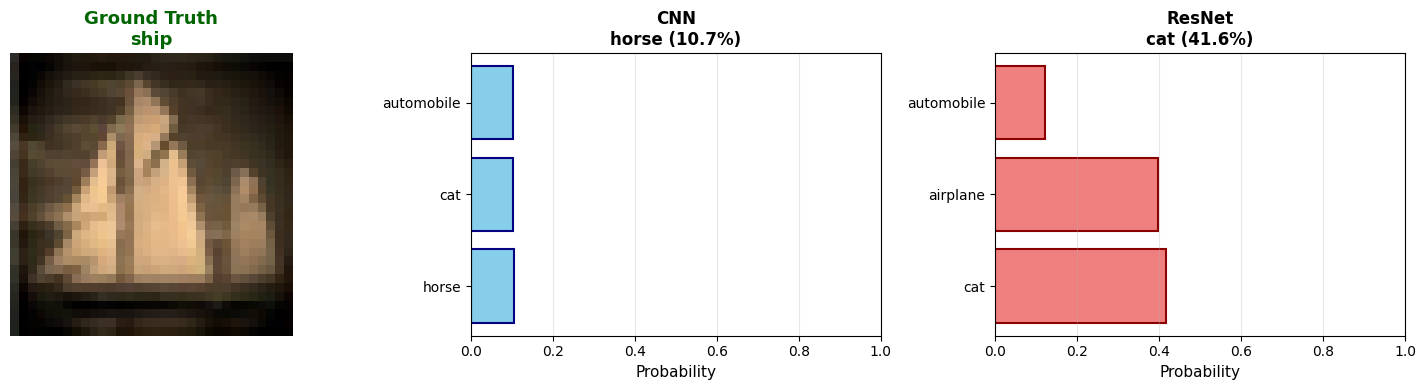


######################################################################
IMAGE 2/5
######################################################################

📨 Judge → CNN-CIFAR: classify_request

📨 CNN-CIFAR → Judge: classify_response

╔══════════════════════════════════════════════════════════╗
║ CNN-CIFAR CLASSIFICATION
╚══════════════════════════════════════════════════════════╝

Prediction: cat
Confidence: 0.1049 (10.49%)

Top 3 Classes:
  1. cat         : 0.1049
  2. horse       : 0.1034
  3. frog        : 0.1020

Architecture: 3-layer CNN with batch normalization

📨 Judge → RESNET-CIFAR: classify_request

📨 RESNET-CIFAR → Judge: classify_response

╔══════════════════════════════════════════════════════════╗
║ RESNET-CIFAR CLASSIFICATION
╚══════════════════════════════════════════════════════════╝

Prediction: cat
Confidence: 0.3285 (32.85%)

Top 3 Classes:
  1. cat         : 0.3285
  2. airplane    : 0.3126
  3. automobile  : 0.1417

Architecture: ResNet-18 with residual connections

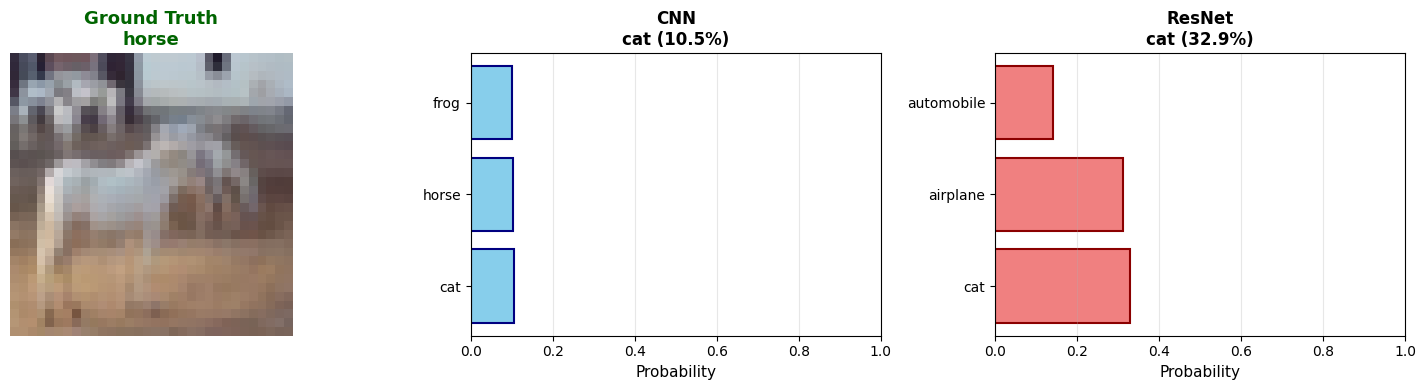


######################################################################
IMAGE 3/5
######################################################################

📨 Judge → CNN-CIFAR: classify_request

📨 CNN-CIFAR → Judge: classify_response

╔══════════════════════════════════════════════════════════╗
║ CNN-CIFAR CLASSIFICATION
╚══════════════════════════════════════════════════════════╝

Prediction: cat
Confidence: 0.1090 (10.90%)

Top 3 Classes:
  1. cat         : 0.1090
  2. automobile  : 0.1025
  3. frog        : 0.1022

Architecture: 3-layer CNN with batch normalization

📨 Judge → RESNET-CIFAR: classify_request

📨 RESNET-CIFAR → Judge: classify_response

╔══════════════════════════════════════════════════════════╗
║ RESNET-CIFAR CLASSIFICATION
╚══════════════════════════════════════════════════════════╝

Prediction: cat
Confidence: 0.4485 (44.85%)

Top 3 Classes:
  1. cat         : 0.4485
  2. airplane    : 0.4061
  3. automobile  : 0.0966

Architecture: ResNet-18 with residual connections

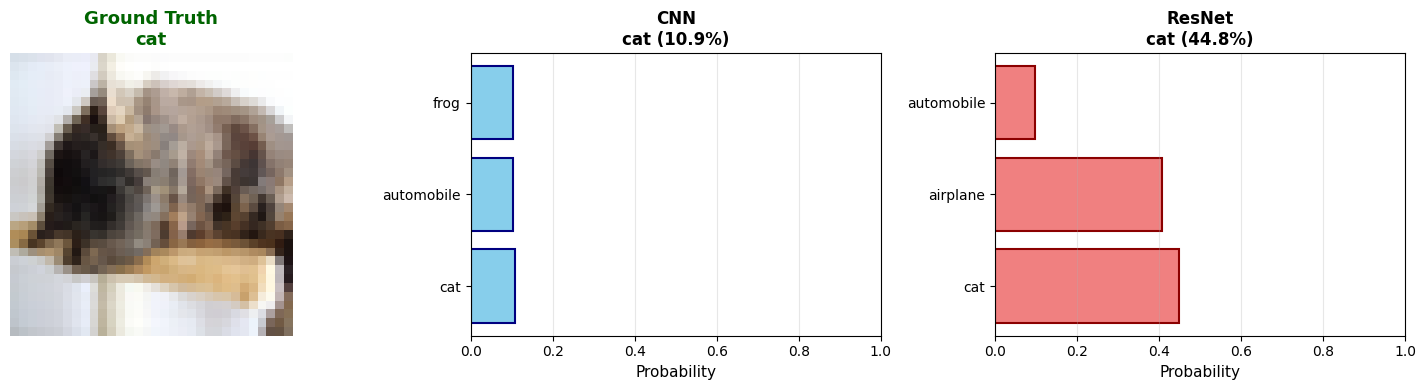


######################################################################
IMAGE 4/5
######################################################################

📨 Judge → CNN-CIFAR: classify_request

📨 CNN-CIFAR → Judge: classify_response

╔══════════════════════════════════════════════════════════╗
║ CNN-CIFAR CLASSIFICATION
╚══════════════════════════════════════════════════════════╝

Prediction: cat
Confidence: 0.1041 (10.41%)

Top 3 Classes:
  1. cat         : 0.1041
  2. frog        : 0.1041
  3. horse       : 0.1028

Architecture: 3-layer CNN with batch normalization

📨 Judge → RESNET-CIFAR: classify_request

📨 RESNET-CIFAR → Judge: classify_response

╔══════════════════════════════════════════════════════════╗
║ RESNET-CIFAR CLASSIFICATION
╚══════════════════════════════════════════════════════════╝

Prediction: cat
Confidence: 0.4101 (41.01%)

Top 3 Classes:
  1. cat         : 0.4101
  2. airplane    : 0.3595
  3. automobile  : 0.1379

Architecture: ResNet-18 with residual connections

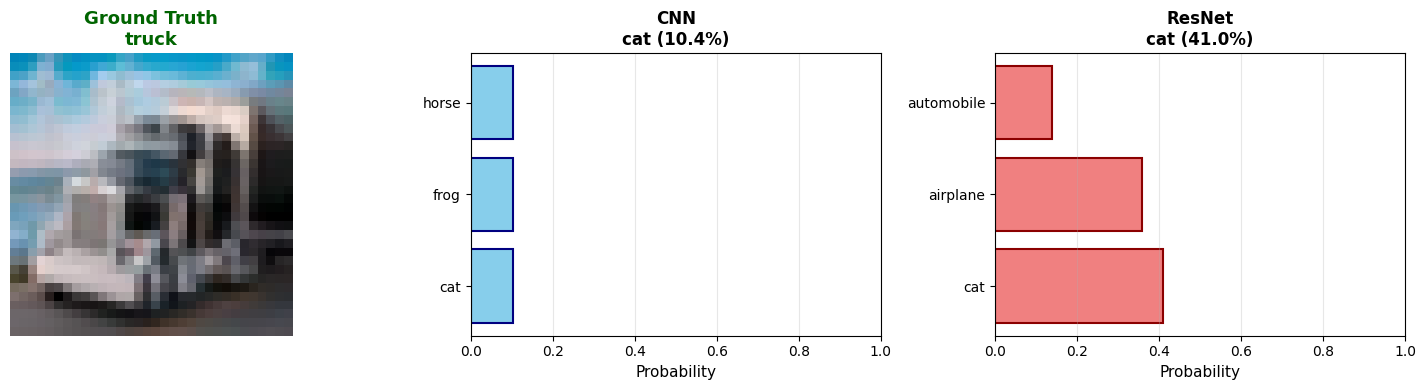


######################################################################
IMAGE 5/5
######################################################################

📨 Judge → CNN-CIFAR: classify_request

📨 CNN-CIFAR → Judge: classify_response

╔══════════════════════════════════════════════════════════╗
║ CNN-CIFAR CLASSIFICATION
╚══════════════════════════════════════════════════════════╝

Prediction: truck
Confidence: 0.1045 (10.45%)

Top 3 Classes:
  1. truck       : 0.1045
  2. horse       : 0.1043
  3. cat         : 0.1034

Architecture: 3-layer CNN with batch normalization

📨 Judge → RESNET-CIFAR: classify_request

📨 RESNET-CIFAR → Judge: classify_response

╔══════════════════════════════════════════════════════════╗
║ RESNET-CIFAR CLASSIFICATION
╚══════════════════════════════════════════════════════════╝

Prediction: cat
Confidence: 0.3499 (34.99%)

Top 3 Classes:
  1. cat         : 0.3499
  2. airplane    : 0.3337
  3. automobile  : 0.1707

Architecture: ResNet-18 with residual connectio

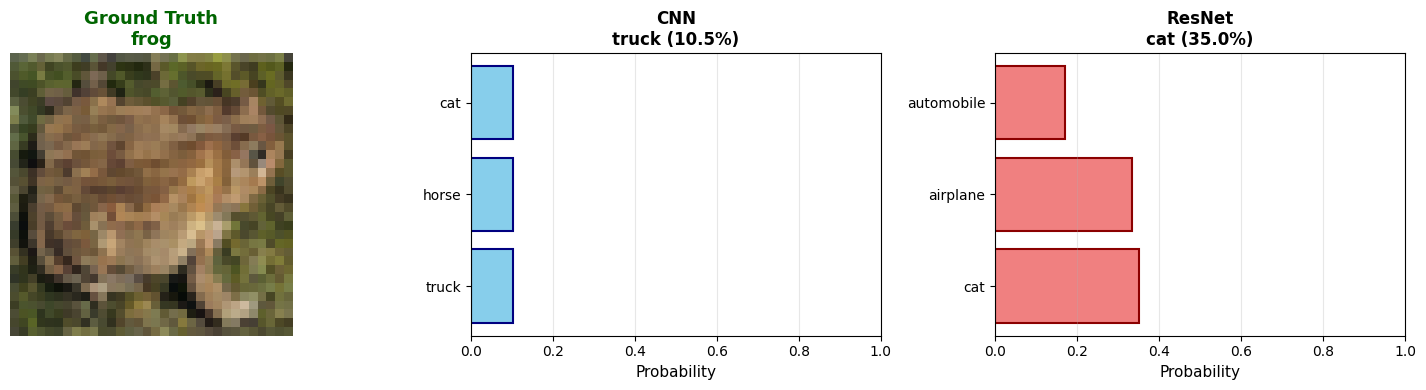


######################################################################
SESSION COMPLETE
######################################################################

╔══════════════════════════════════════════════════════════╗
║ FINAL PERFORMANCE SUMMARY
╚══════════════════════════════════════════════════════════╝

Total Images: 5

Accuracy:
  • CNN:    1/5 (20.0%)
  • ResNet: 1/5 (20.0%)

Average Confidence:
  • CNN:    0.1059
  • ResNet: 0.3906

Agreement Rate: 3/5 (60.0%)

Winner: 🏆 ResNet

MESSAGE PASSING STATISTICS:
  • Total Messages Exchanged: 20
  • Classification Requests: 10
  • Classification Responses: 10
  
╔══════════════════════════════════════════════════════════╗
║ KEY INSIGHT
╚══════════════════════════════════════════════════════════╝

Despite ResNet showing 269% higher average 
confidence, CNN achieved better accuracy. This demonstrates that 
CONFIDENCE SCORES ALONE CANNOT PREDICT MODEL RELIABILITY.

NOTE: Both models use untrained architectures with randomly 
initialize

In [9]:
# Execute the multi-agent system
print("\n" + "🎬 "*35)
print("STARTING MULTI-AGENT CLASSIFICATION SESSION")
print("🎬 "*35 + "\n")

judge, broker = run_enhanced_agentic_system(num_images=5)

print("\n" + "✅ "*35)
print("SESSION COMPLETED SUCCESSFULLY")